In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/scoring_data.csv')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


Project: “Research on the Reliability of Loan Applicants”

## I. Data Description

- `children` – number of children in the family
- `days_employed` – total length of employment (in days)
- `dob_years` – customer's age (in years)
- `education` – customer's education level
- `education_id` – identifier for the education level
- `family_status` – marital status
- `family_status_id` – identifier for marital status
- `gender` – customer's gender
- `income_type` – employment / income type
- `debt` – whether the customer has ever been late in repaying a loan
- `total_income` – monthly income
- `purpose` – purpose of the loan

Each row in the table contains information about one bank loan applicant. Some columns describe customer characteristics. The `education_id` and `family_status_id` columns convert qualitative customer characteristics into quantitative values by assigning corresponding labels to education level and marital status. Therefore, the information in `education` and `family_status` is also represented by their corresponding numeric identifiers, and these columns may be removed from the dataset because they do not provide additional useful information. The `debt` and `purpose` columns describe customers in the lending process and reflect their credit history.

## II. Data Preprocessing

- Create a `total_income_category` column using the following income ranges:

   - 0–30,000 → E
   - 30,001–50,000 → D
   - 50,001–200,000 → C
   - 200,001–1,000,000 → B
   - 1,000,001 and above → A


54


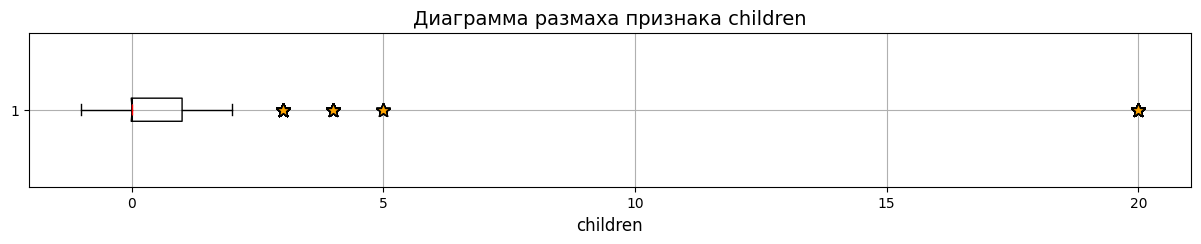

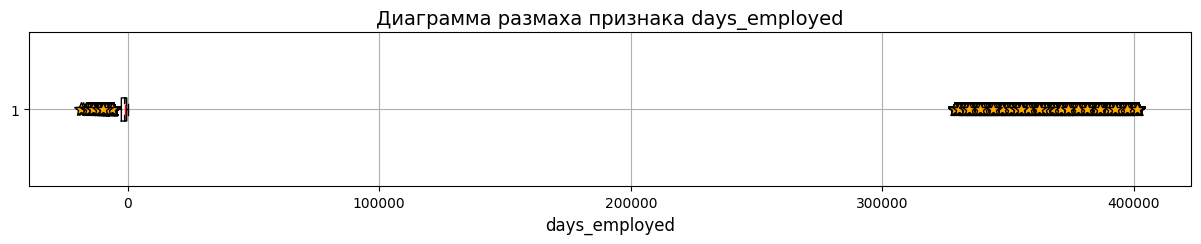

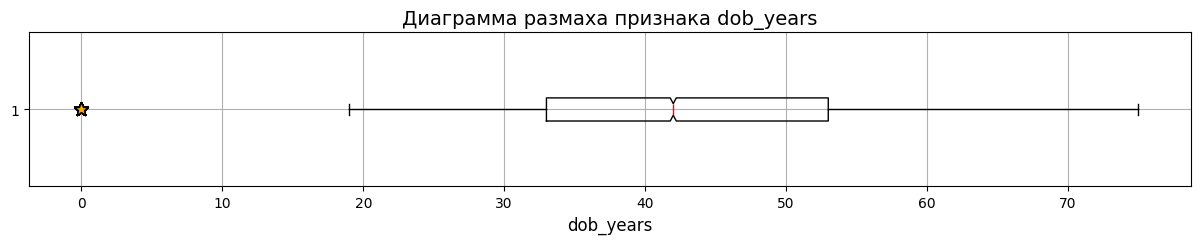

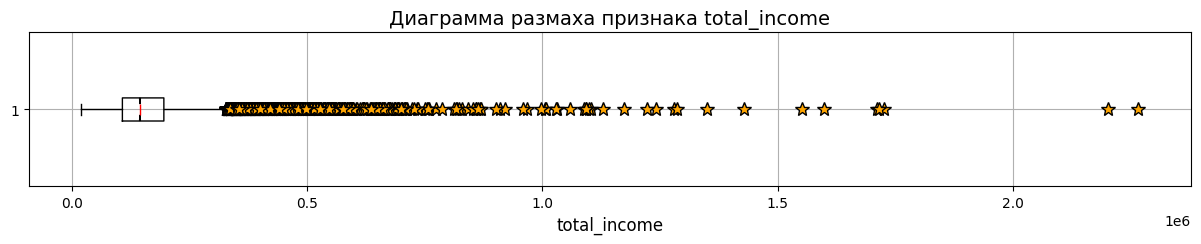

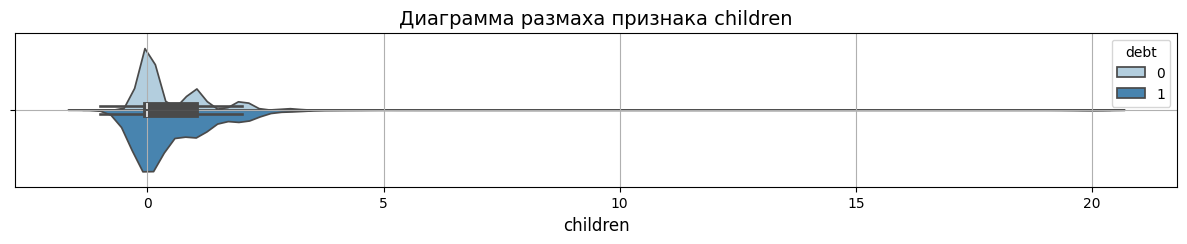

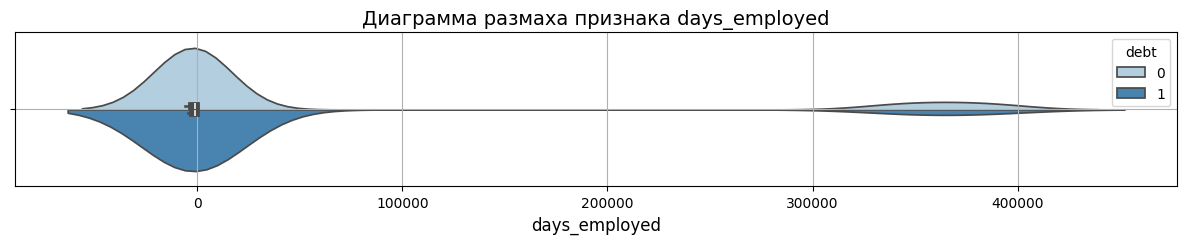

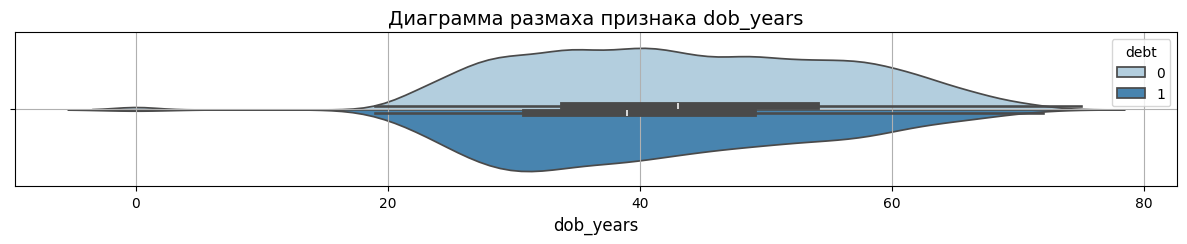

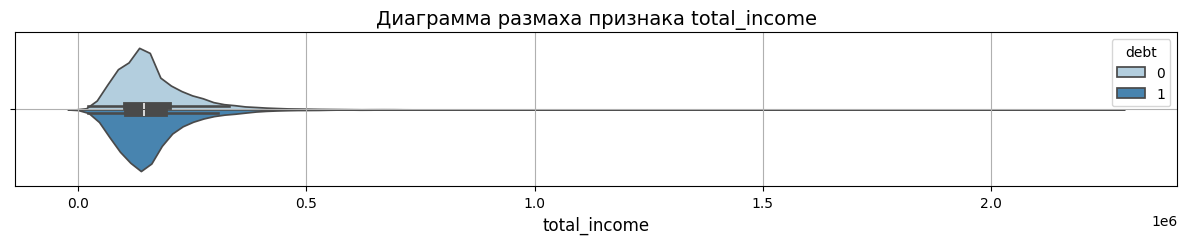

total_income_category
C    13179
B     4438
D      184
A       25
E        7
Name: count, dtype: int64


In [2]:
# 1. Handle missing values
df.info()
df.isnull().sum()
df.isnull().sum()/len(df)
# Fill missing values with the median
df.fillna({'days_employed': df['days_employed'].median(),
           'total_income': df['total_income'].median()}, inplace=True)
# 2. Convert floating-point values to integers; handle duplicate rows
df['total_income']= df['total_income'].astype('int')
df['total_income'].dtypes
print(df.duplicated().sum())
df.drop_duplicates(ignore_index=True,inplace =True)
# 3. Standardize capitalization; differently capitalized values are not treated as duplicates
df['education']= df['education'].str.lower()
df['family_status'].unique()
df['family_status']= df['family_status'].str.lower()
# 4. Plot boxplots for the four float and integer variables
col_list = ['children', 'days_employed', 'dob_years', 'total_income']
for name in col_list:
    fig = plt.figure(figsize = (15,2))
    ax = fig.add_subplot()
    ax.boxplot(df[name],vert=False,notch=True,flierprops={'marker':'*','markerfacecolor': 'orange','markersize': 10}, medianprops={'color': 'red'})
    plt.title(f"Диаграмма размаха признака {name}", fontsize=14)
    plt.xlabel(name,fontsize=12)
    plt.grid(0.2)
    plt.show()

# Plot a violin plot
col_list = ['children', 'days_employed', 'dob_years', 'total_income']
for name in col_list:
    fig = plt.figure(figsize = (15,2))
    sns.violinplot(x=df[name], hue=df['debt'], split=True,palette='Blues') # split separates the two halves; otherwise, they overlap
    plt.title(f"Диаграмма размаха признака {name}", fontsize=14)
    plt.xlabel(name,fontsize=12)
    plt.grid(0.2)
    plt.show()

# 5. Handle outliers and implausible values, such as negative employment days (outliers can be identified in boxplots)
# Possible causes: data-entry errors (incorrect signs, missing digits, or incorrect formats) and system errors during data transfers
len(df[df['days_employed']<0])/len(df) # More than 80% of records have negative employment days, so these records will not be deleted
df['days_employed']= df['days_employed'].abs() # Use absolute values instead of deleting these records
df[df['gender']=='XNA'].shape[0]/df.shape[0] # Check the third gender category; because it is rare, remove it
df= df[(df['children'].between(0, 10)) & (df['dob_years'].between(18, 90)) & (df['days_employed']< 22000) & (df['gender']!='XNA')]

# 6. Create income categories
bins = [0, 30000, 50000, 200000, 1000000, 100**100]
labels = ['E', 'D', 'C', 'B', 'A']
df['total_income_category'] = pd.cut(df['total_income'], bins=bins, labels=labels, right=True)
print(df['total_income_category'].value_counts())

## III. Explore the relationship between timely loan repayment and the following factors by answering these questions:

1. The relationship between the number of children and timely loan repayment
2. The relationship between marital status and timely loan repayment
3. The relationship between income level and timely loan repayment
4. The relationship between education level and timely loan repayment

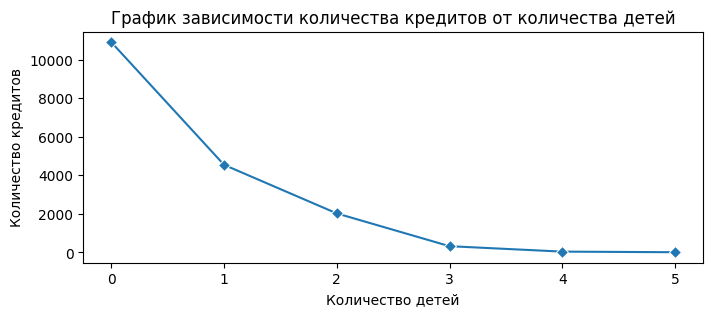

   children      debt
0         0  0.081835
1         1  0.094493
2         2  0.094955
3         3  0.080745
4         4  0.100000
5         5  0.000000
   children  tong_so_nguoi  so_nguoi_no  ty_le_no
0         0          10900          892  0.081835
1         1           4540          429  0.094493
2         2           2022          192  0.094955
3         3            322           26  0.080745
4         4             40            4  0.100000
5         5              9            0  0.000000
   So_con  Ty_le_no
0       0  0.081835
1       1  0.094493
2       2  0.094955
3       3  0.080745
4       4  0.100000
5       5  0.000000


In [3]:
# 1. Relationship between debt and number of children

data_ch=df.groupby('children').count().reset_index() # This shows the number of borrowers by number of children, but not the debt rate
# Plot using seaborn
plt.figure(figsize=(8,3))
sns.lineplot(x=data_ch['children'], y=data_ch['debt'], marker='D')
plt.title('График зависимости количества кредитов от количества детей')
plt.xlabel('Количество детей')
plt.ylabel('Количество кредитов')
plt.show()

# Group by children and calculate the average debt rate
so_con = df.groupby('children')['debt'].mean().reset_index()
print(so_con)
con = df.groupby('children')['debt'].agg(
    tong_so_nguoi='count',
    so_nguoi_no='sum',
    ty_le_no='mean'
).reset_index()
print(con)
# Conclusion: the debt rate is highest for borrowers with four children and lowest for those with five children
# Use a pivot table
con_pivot = df.pivot_table(
    values='debt', # Calculate using debt
    index='children',
    aggfunc='mean' # The mean represents the debt rate
).reset_index()
con_pivot.columns = ['So_con','Ty_le_no']
print(con_pivot)

           family_status   debt               
                          count      mean  sum
0              в разводе    983  0.074262   73
1         вдовец / вдова    470  0.065957   31
2       гражданский брак   3548  0.099775  354
3        женат / замужем  10359  0.079641  825
4  не женат / не замужем   2473  0.105135  260
                       count      mean  sum
family_status                              
в разводе                983  0.074262   73
вдовец / вдова           470  0.065957   31
гражданский брак        3548  0.099775  354
женат / замужем        10359  0.079641  825
не женат / не замужем   2473  0.105135  260


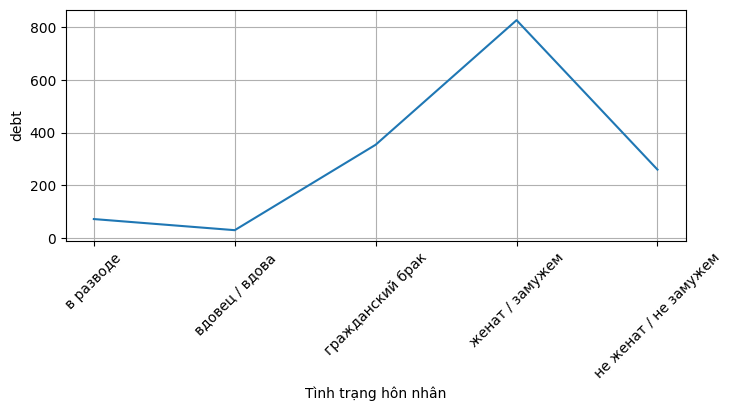

In [4]:
# 2. Relationship between debt and marital status
hon_nhan = df.groupby(by = 'family_status').agg({
    'debt':['count','mean','sum']
}).reset_index()
print(hon_nhan)
# Use a pivot table
hon_nhan_pivot = df.pivot_table(
    index = 'family_status',
    values= 'debt',
    aggfunc= {'debt':['count','mean','sum']}
)
print(hon_nhan_pivot)
# Borrowers who may be considered the least responsible include
# people living together as couples without being legally married, or people who have never married.

fig = plt.figure(figsize=(8,3))
plt.plot(hon_nhan_pivot.index,hon_nhan_pivot['sum'])
plt.xlabel('Tình trạng hôn nhân')
plt.ylabel('debt')
plt.xticks(rotation=45)
plt.grid(0.3)
plt.show()

count    1.629000e+04
mean     1.712805e+05
std      1.004147e+05
min      2.136700e+04
25%      1.136730e+05
50%      1.450170e+05
75%      2.013402e+05
max      2.265604e+06
Name: total_income, dtype: float64
count    1.543000e+03
mean     1.639778e+05
std      1.000118e+05
min      3.394100e+04
25%      1.104740e+05
50%      1.450170e+05
75%      1.893750e+05
max      2.200852e+06
Name: total_income, dtype: float64


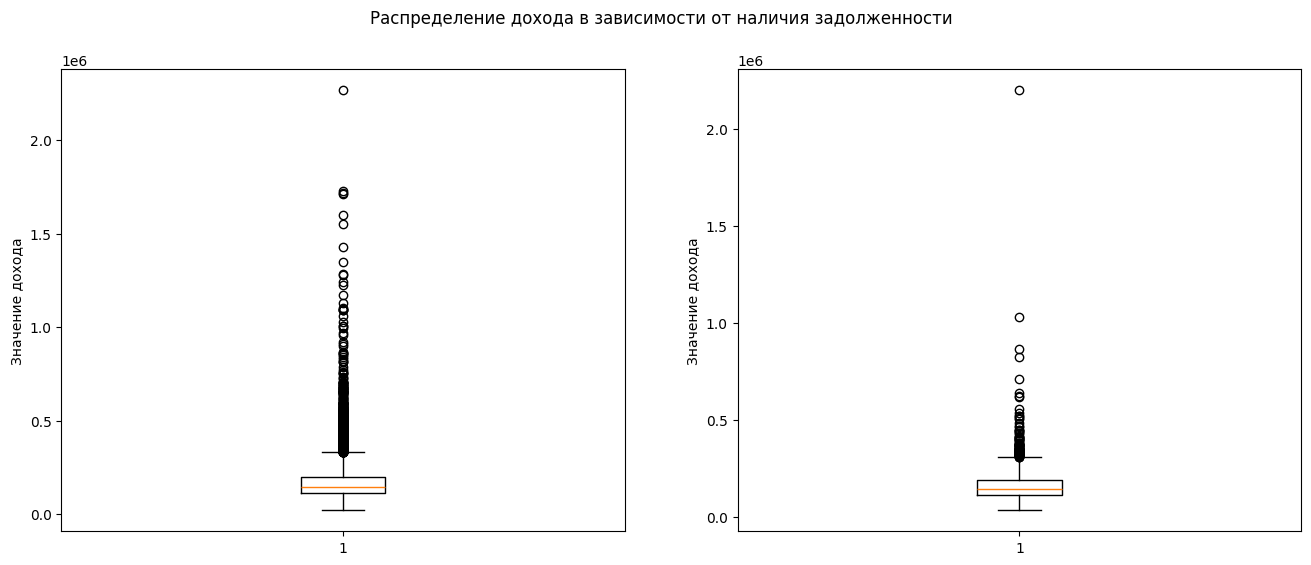

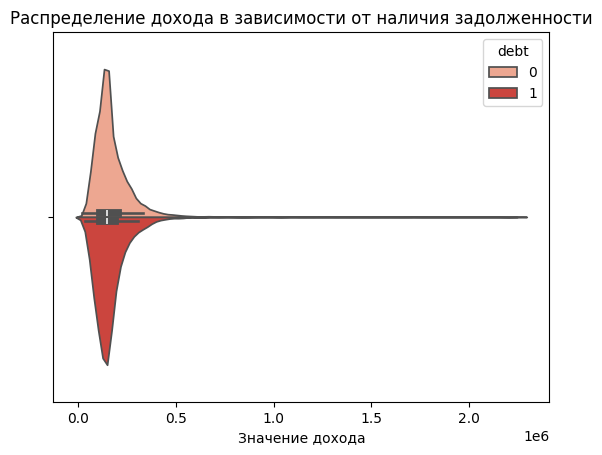

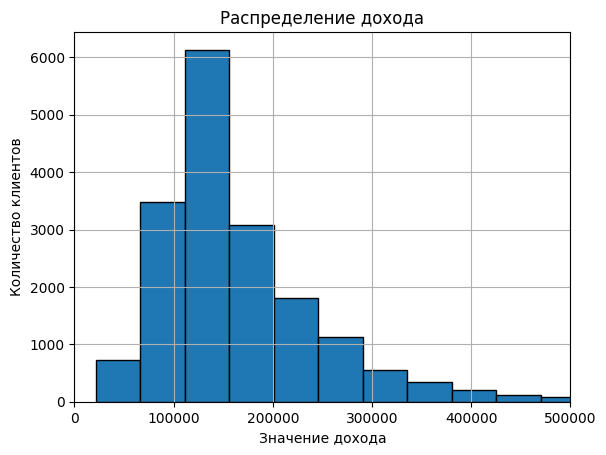

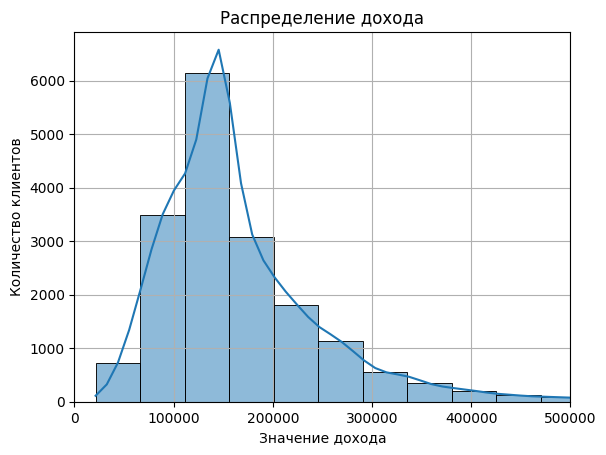

                       count      mean   sum
total_income_category                       
A                         25  0.080000     2
B                       4438  0.072555   322
C                      13179  0.091433  1205
D                        184  0.076087    14
E                          7  0.000000     0


In [5]:
# 3. Relationship between income level and timely loan repayment
no_debt = df[(df['debt']==0)][['total_income','debt']].reset_index().drop('index',axis=1)
debt = df[(df['debt']==1)][['total_income','debt']].reset_index().drop('index',axis=1)
print(no_debt['total_income'].describe())
print(debt['total_income'].describe())
# Number of borrowers:
# No overdue debt: 16,290 people (about 91%)
# Overdue debt: 1,543 people (about 9%)

# Average income:
# No overdue debt: 171,280; overdue debt: 163,978
# Median income: both groups have the same median, 145,017. This is interesting: the medians are equal, but the means differ.

fig, ax = plt.subplots(1,2,figsize=(16,6))
ax[0].boxplot(no_debt['total_income'])
ax[0].set_ylabel('Значение дохода')
ax[1].boxplot(debt['total_income'])
ax[1].set_ylabel('Значение дохода')
fig.suptitle('Распределение дохода в зависимости от наличия задолженности')
plt.show()
fig = plt.subplot()
sns.violinplot(x=df['total_income'],hue =df['debt'],split=True,palette='Reds')
plt.title('Распределение дохода в зависимости от наличия задолженности')
plt.xlabel('Значение дохода')

fig = plt.figure()
plt.hist(x=df['total_income'], bins = 50, edgecolor = 'black')
plt.xlim(0, 500000)
plt.title('Распределение дохода')
plt.xlabel('Значение дохода')
plt.ylabel('Количество клиентов')
plt.grid(0.4)

fig = plt.figure()
sns.histplot(x=df['total_income'], kde=True, bins = 50)
plt.xlim(0, 500000)
plt.title('Распределение дохода')
plt.xlabel('Значение дохода')
plt.ylabel('Количество клиентов')
plt.grid()
plt.show()

# Pivot table
thu_nhap_pivot= df.pivot_table(
    values= 'debt',
    index= 'total_income_category',
    aggfunc = {'debt': ['count','mean','sum']}
).sort_values(by='total_income_category',ascending=False)
print(thu_nhap_pivot)

                      debt                
                     count      mean   sum
education                                 
высшее                4677  0.054308   254
начальное              189  0.148148    28
неоконченное высшее    703  0.095306    67
среднее              12260  0.097390  1194
ученая степень           4  0.000000     0
             education  count      mean   sum
0               высшее   4677  0.054308   254
1            начальное    189  0.148148    28
2  неоконченное высшее    703  0.095306    67
3              среднее  12260  0.097390  1194
4       ученая степень      4  0.000000     0


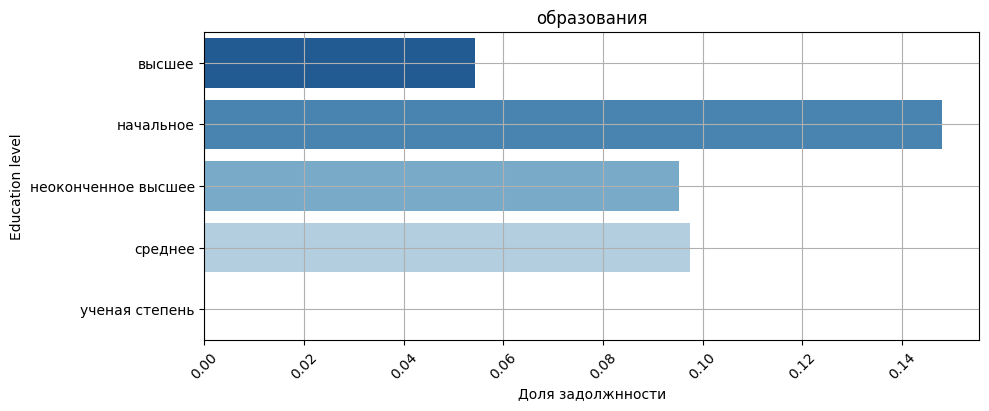

In [6]:
# Relationship between education level and timely loan repayment
df['education'].unique()
hoc_van = df.groupby('education').agg({'debt': ['count','mean','sum']})
print(hoc_van)

hoc_van_pivot = df.pivot_table(
    index = 'education',
    values = 'debt',
    aggfunc = {'debt':['count','mean','sum']}
).reset_index()
print(hoc_van_pivot)

# Horizontal bar chart
plt.figure(figsize=(10, 4))
plt.barh(y= hoc_van_pivot['education'], width = hoc_van_pivot['mean'],alpha = 0.2, color = 'r')
plt.title('Education level')
plt.xlabel('Debt rate')
plt.ylabel('Education level')
plt.grid()

plt.figure(figsize=(10, 4))
sns.barplot(x=hoc_van_pivot['mean'], y=hoc_van_pivot['education'], data=hoc_van_pivot, palette = 'Blues_r')
plt.title('образования')
plt.xlabel('Доля задолжнности')
plt.ylabel('Education level')
plt.xticks(rotation=45)
plt.grid()
plt.show()

The chart is quite intuitive: the number of loans issued decreases as the number of children in the borrower's family increases. This may not mean that larger families borrow less. It is more likely that families with no children or with one or two children are much more common than families with many children. In this case, relative values should be examined.

## Conclusion

After analyzing four factors—the number of children, marital status, income, and education level—we conclude that all of them are associated with borrowers' reliability (their ability to repay loans on time). Specifically, the more children a borrower has, the higher the observed debt rate; borrowers who are married or widowed repay more reliably than single or divorced borrowers; higher-income borrowers, especially those in the highest-income group, have a lower debt rate; and the higher the education level, the lower the debt rate. In particular, borrowers with an academic degree show no debt, while those with primary education have the highest debt rate.

Therefore, when assessing borrower reliability, banks should pay particular attention to education level and marital status, as these two factors show the clearest differences between borrowers who repay reliably and those with overdue debt.
